<a href="https://colab.research.google.com/github/Pstone123/SPIM-Digital-Twin-PPO/blob/main/SPIM_Paper2_Architecture_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os, pickle, torch, torch.nn as nn
import numpy as np
import time
from sklearn.metrics import r2_score

drive.mount('/content/drive', force_remount=True)

PROJECT_FOLDER = '/content/drive/MyDrive/SPIM_PhD_Research'
DATA_FOLDER    = f'{PROJECT_FOLDER}/data'
MODELS_FOLDER  = f'{PROJECT_FOLDER}/models'
PLOTS_FOLDER   = f'{PROJECT_FOLDER}/plots'

device = torch.device('cpu')
torch.manual_seed(42)
np.random.seed(42)

print('Google Drive mounted')
print(f'Device: {device}')

Mounted at /content/drive
Google Drive mounted
Device: cpu


In [2]:
import torch.utils.data as data_utils
from sklearn.preprocessing import MinMaxScaler

# Load original scaler and dataset (Paper 1 — same data for fair comparison)
with open(f'{MODELS_FOLDER}/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

X_train = np.load(f'{DATA_FOLDER}/X_train.npy')
X_val   = np.load(f'{DATA_FOLDER}/X_val.npy')
Y_train = np.load(f'{DATA_FOLDER}/Y_train.npy')
Y_val   = np.load(f'{DATA_FOLDER}/Y_val.npy')

X_tr_t = torch.FloatTensor(X_train).to(device)
X_vl_t = torch.FloatTensor(X_val).to(device)
Y_tr_t = torch.FloatTensor(Y_train).to(device)
Y_vl_t = torch.FloatTensor(Y_val).to(device)

print(f'Dataset loaded')
print(f'X_train: {X_train.shape}')
print(f'X_val:   {X_val.shape}')
print(f'Features: V_motor, I_main, I_aux, torque, speed_RPM')
print(f'Sequence length: 20 timesteps')

Dataset loaded
X_train: (7584, 20, 5)
X_val:   (1897, 20, 5)
Features: V_motor, I_main, I_aux, torque, speed_RPM
Sequence length: 20 timesteps


In [3]:
# ── ARCHITECTURE 1: Residual LSTM (Paper 1 baseline) ────────
class ResidualLSTM(nn.Module):
    def __init__(self):
        super(ResidualLSTM, self).__init__()
        self.lstm1    = nn.LSTM(5, 64, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)
        self.lstm2    = nn.LSTM(64, 32, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)
        self.fc       = nn.Linear(32, 1)

    def forward(self, x):
        last_speed = x[:, -1, 4:5]
        out, _     = self.lstm1(x)
        out        = self.dropout1(out)
        out, _     = self.lstm2(out)
        out        = self.dropout2(out)
        out        = out[:, -1, :]
        delta      = self.fc(out)
        return last_speed + delta

# ── ARCHITECTURE 2: Residual GRU ────────────────────────────
class ResidualGRU(nn.Module):
    def __init__(self):
        super(ResidualGRU, self).__init__()
        self.gru1     = nn.GRU(5, 64, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)
        self.gru2     = nn.GRU(64, 32, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)
        self.fc       = nn.Linear(32, 1)

    def forward(self, x):
        last_speed = x[:, -1, 4:5]
        out, _     = self.gru1(x)
        out        = self.dropout1(out)
        out, _     = self.gru2(out)
        out        = self.dropout2(out)
        out        = out[:, -1, :]
        delta      = self.fc(out)
        return last_speed + delta

# ── ARCHITECTURE 3: Residual Transformer ────────────────────
class ResidualTransformer(nn.Module):
    def __init__(self, d_model=64, nhead=4, num_layers=2,
                 dropout=0.2):
        super(ResidualTransformer, self).__init__()
        self.input_proj = nn.Linear(5, d_model)
        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=128, dropout=dropout,
            batch_first=True)
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(d_model, 1)

    def forward(self, x):
        last_speed = x[:, -1, 4:5]
        out        = self.input_proj(x)
        out        = self.transformer(out)
        out        = self.dropout(out[:, -1, :])
        delta      = self.fc(out)
        return last_speed + delta

# ── TRAINING FUNCTION ────────────────────────────────────────
def train_model(model, name):
    loader = data_utils.DataLoader(
        data_utils.TensorDataset(X_tr_t, Y_tr_t),
        batch_size=64, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5)
    criterion = nn.MSELoss()

    EPOCHS=100; PATIENCE=10
    best_val=float('inf'); pat_count=0; best_state=None
    train_losses=[]; val_losses=[]

    print(f'Training {name}...')
    start = time.time()

    for epoch in range(EPOCHS):
        model.train()
        ep_loss = 0
        for Xb, Yb in loader:
            optimizer.zero_grad()
            pred = model(Xb)
            loss = criterion(pred, Yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            ep_loss += loss.item()
        avg_tr = ep_loss / len(loader)
        train_losses.append(avg_tr)

        model.eval()
        with torch.no_grad():
            vl = criterion(model(X_vl_t), Y_vl_t).item()
        val_losses.append(vl)
        scheduler.step(vl)

        if vl < best_val:
            best_val=vl; pat_count=0
            best_state={k:v.clone() for k,v in model.state_dict().items()}
        else:
            pat_count+=1

        if pat_count>=PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

    model.load_state_dict(best_state)
    elapsed = time.time() - start
    print(f'Done in {elapsed:.0f}s | Best val loss: {best_val:.8f}')
    return model, elapsed, best_val, train_losses, val_losses

# ── EVALUATION FUNCTION ──────────────────────────────────────
def evaluate_model(model, name, elapsed):
    model.eval()

    def to_rpm(norm):
        d = np.zeros((len(norm), 5))
        d[:,4] = norm.flatten()
        return scaler.inverse_transform(d)[:,4]

    with torch.no_grad():
        Y_pred_n = model(X_vl_t).cpu().numpy()
        Y_true_n = Y_vl_t.cpu().numpy()

    Y_pred = to_rpm(Y_pred_n)
    Y_true = to_rpm(Y_true_n)

    r2   = r2_score(Y_true, Y_pred)
    rmse = np.sqrt(np.mean((Y_pred - Y_true)**2))
    mae  = np.mean(np.abs(Y_pred - Y_true))

    # Inference time — average over 200 runs
    single = X_vl_t[:1]
    times  = []
    for _ in range(200):
        t0 = time.perf_counter()
        with torch.no_grad():
            _ = model(single)
        times.append((time.perf_counter()-t0)*1000)
    inf_time = np.mean(times[20:])  # drop warmup

    params = sum(p.numel() for p in model.parameters())

    print(f'\n{name} Evaluation:')
    print(f'  R²:             {r2:.4f} ({r2*100:.2f}%)')
    print(f'  RMSE:           {rmse:.4f} RPM')
    print(f'  MAE:            {mae:.4f} RPM')
    print(f'  Training time:  {elapsed:.0f} seconds')
    print(f'  Inference time: {inf_time:.4f} ms per step')
    print(f'  Parameters:     {params:,}')

    return {'name':name, 'r2':r2, 'rmse':rmse, 'mae':mae,
            'train_time':elapsed, 'inf_time':inf_time,
            'params':params}

print('All architectures and functions defined')
print('Ready to train')

All architectures and functions defined
Ready to train


In [4]:
# ── TRAIN ALL THREE ──────────────────────────────────────────
all_results = {}

# 1. Residual LSTM
lstm_model = ResidualLSTM().to(device)
lstm_model, lstm_time, lstm_val, lstm_tr_loss, lstm_vl_loss = train_model(lstm_model, 'Residual LSTM')
lstm_results = evaluate_model(lstm_model, 'Residual LSTM', lstm_time)
all_results['LSTM'] = lstm_results
torch.save({'model_state_dict': lstm_model.state_dict(), **lstm_results},
           f'{MODELS_FOLDER}/paper2_lstm.pth')
print('LSTM saved\n')

# 2. Residual GRU
gru_model = ResidualGRU().to(device)
gru_model, gru_time, gru_val, gru_tr_loss, gru_vl_loss = train_model(gru_model, 'Residual GRU')
gru_results = evaluate_model(gru_model, 'Residual GRU', gru_time)
all_results['GRU'] = gru_results
torch.save({'model_state_dict': gru_model.state_dict(), **gru_results},
           f'{MODELS_FOLDER}/paper2_gru.pth')
print('GRU saved\n')

# 3. Residual Transformer
trans_model = ResidualTransformer().to(device)
trans_model, trans_time, trans_val, trans_tr_loss, trans_vl_loss = train_model(trans_model, 'Residual Transformer')
trans_results = evaluate_model(trans_model, 'Residual Transformer', trans_time)
all_results['Transformer'] = trans_results
torch.save({'model_state_dict': trans_model.state_dict(), **trans_results},
           f'{MODELS_FOLDER}/paper2_transformer.pth')
print('Transformer saved\n')

print('='*55)
print('COMPLETE COMPARISON SUMMARY')
print('='*55)
print(f"{'Model':<22} {'R2%':>7} {'RMSE':>8} {'MAE':>8} {'Time(s)':>9} {'Inf(ms)':>9} {'Params':>9}")
print('-'*55)
for k, v in all_results.items():
    print(f"{v['name']:<22} {v['r2']*100:>7.2f} {v['rmse']:>8.4f} {v['mae']:>8.4f} {v['train_time']:>9.0f} {v['inf_time']:>9.4f} {v['params']:>9,}")

Training Residual LSTM...
Early stopping at epoch 14
Done in 35s | Best val loss: 0.00000813

Residual LSTM Evaluation:
  R²:             0.9778 (97.78%)
  RMSE:           2.1239 RPM
  MAE:            1.6731 RPM
  Training time:  35 seconds
  Inference time: 0.6814 ms per step
  Parameters:     30,753
LSTM saved

Training Residual GRU...
Early stopping at epoch 25
Done in 78s | Best val loss: 0.00000488

Residual GRU Evaluation:
  R²:             0.9867 (98.67%)
  RMSE:           1.6451 RPM
  MAE:            1.2428 RPM
  Training time:  78 seconds
  Inference time: 2.4148 ms per step
  Parameters:     23,073
GRU saved

Training Residual Transformer...
Early stopping at epoch 14
Done in 85s | Best val loss: 0.00000889

Residual Transformer Evaluation:
  R²:             0.9757 (97.57%)
  RMSE:           2.2211 RPM
  MAE:            1.7908 RPM
  Training time:  85 seconds
  Inference time: 0.7251 ms per step
  Parameters:     67,393
Transformer saved

COMPLETE COMPARISON SUMMARY
Model    

In [5]:
# ── ABLATION: Standard LSTM (no residual) ───────────────────
class StandardLSTM(nn.Module):
    def __init__(self):
        super(StandardLSTM, self).__init__()
        self.lstm1    = nn.LSTM(5, 64, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)
        self.lstm2    = nn.LSTM(64, 32, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)
        self.fc       = nn.Linear(32, 1)

    def forward(self, x):
        out, _  = self.lstm1(x)
        out     = self.dropout1(out)
        out, _  = self.lstm2(out)
        out     = self.dropout2(out)
        out     = out[:, -1, :]
        return self.fc(out)  # NO residual

class StandardGRU(nn.Module):
    def __init__(self):
        super(StandardGRU, self).__init__()
        self.gru1     = nn.GRU(5, 64, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)
        self.gru2     = nn.GRU(64, 32, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)
        self.fc       = nn.Linear(32, 1)

    def forward(self, x):
        out, _  = self.gru1(x)
        out     = self.dropout1(out)
        out, _  = self.gru2(out)
        out     = self.dropout2(out)
        out     = out[:, -1, :]
        return self.fc(out)  # NO residual

class StandardTransformer(nn.Module):
    def __init__(self, d_model=64, nhead=4,
                 num_layers=2, dropout=0.2):
        super(StandardTransformer, self).__init__()
        self.input_proj = nn.Linear(5, d_model)
        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=128, dropout=dropout,
            batch_first=True)
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(d_model, 1)

    def forward(self, x):
        out   = self.input_proj(x)
        out   = self.transformer(out)
        out   = self.dropout(out[:, -1, :])
        return self.fc(out)  # NO residual

# Train all three standard versions
ablation_results = {}

for ModelClass, name in [(StandardLSTM, 'Standard LSTM'),
                          (StandardGRU,  'Standard GRU'),
                          (StandardTransformer, 'Standard Transformer')]:
    model = ModelClass().to(device)
    model, t, _, _, _ = train_model(model, name)
    results = evaluate_model(model, name, t)
    ablation_results[name] = results

print('\nABLATION STUDY — Without Residual Connection')
print('='*55)
print(f"{'Model':<25} {'R2%':>7} {'RMSE':>8} {'MAE':>8}")
print('-'*55)
for k, v in ablation_results.items():
    print(f"{v['name']:<25} {v['r2']*100:>7.2f} {v['rmse']:>8.4f} {v['mae']:>8.4f}")

Training Standard LSTM...
Early stopping at epoch 21
Done in 54s | Best val loss: 0.00004584

Standard LSTM Evaluation:
  R²:             0.8746 (87.46%)
  RMSE:           5.0424 RPM
  MAE:            4.4135 RPM
  Training time:  54 seconds
  Inference time: 0.6714 ms per step
  Parameters:     30,753
Training Standard GRU...
Early stopping at epoch 17
Done in 54s | Best val loss: 0.00002076

Standard GRU Evaluation:
  R²:             0.9432 (94.32%)
  RMSE:           3.3936 RPM
  MAE:            2.6007 RPM
  Training time:  54 seconds
  Inference time: 1.4326 ms per step
  Parameters:     23,073
Training Standard Transformer...
Early stopping at epoch 15
Done in 90s | Best val loss: 0.00003686

Standard Transformer Evaluation:
  R²:             0.8992 (89.92%)
  RMSE:           4.5213 RPM
  MAE:            3.7063 RPM
  Training time:  90 seconds
  Inference time: 0.5599 ms per step
  Parameters:     67,393

ABLATION STUDY — Without Residual Connection
Model                         R2%

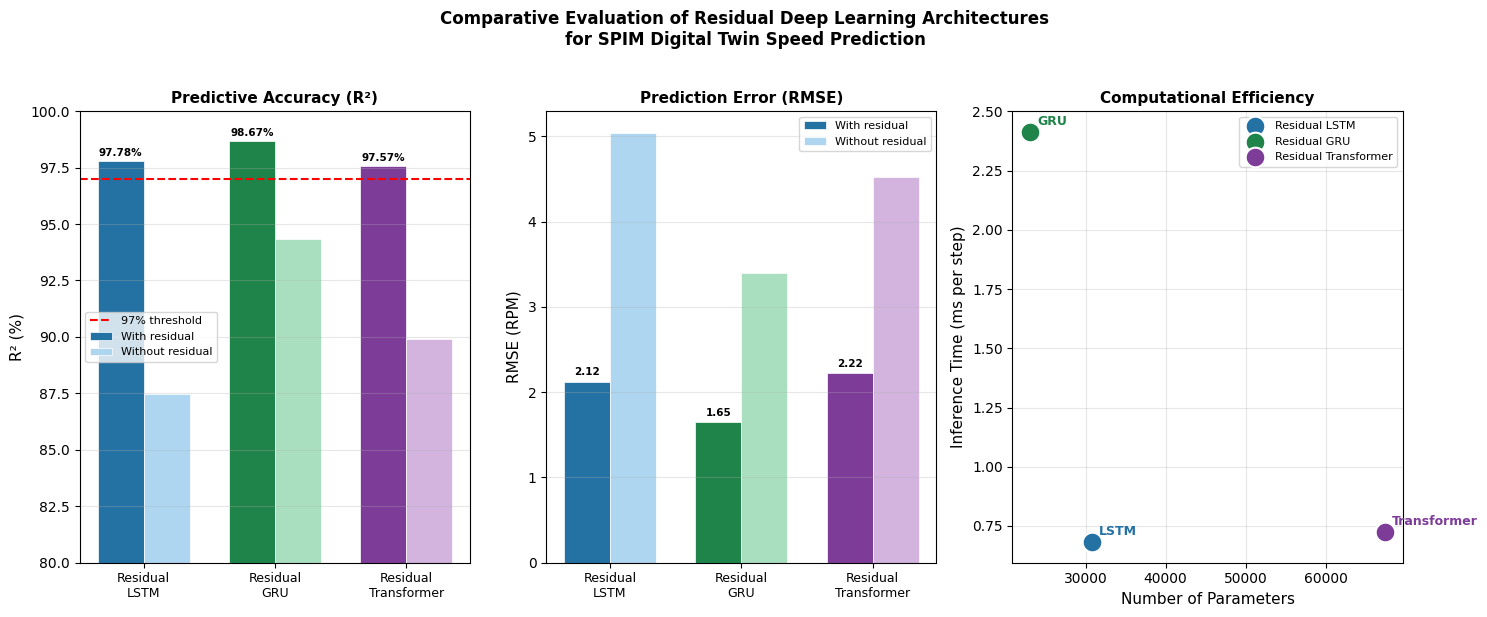

Figure saved to Google Drive


In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

models    = ['Residual\nLSTM', 'Residual\nGRU', 'Residual\nTransformer']
std_models = ['Standard\nLSTM', 'Standard\nGRU', 'Standard\nTransformer']

r2_res  = [97.78, 98.67, 97.57]
r2_std  = [87.46, 94.32, 89.92]
rmse_res = [2.1239, 1.6451, 2.2211]
rmse_std = [5.0424, 3.3936, 4.5213]
inf_res  = [0.6814, 2.4148, 0.7251]
params   = [30753, 23073, 67393]

colors_res = ['#2471A3', '#1E8449', '#7D3C98']
colors_std = ['#AED6F1', '#A9DFBF', '#D2B4DE']
x = np.arange(3)
w = 0.35

# Plot 1 — R² comparison
ax = axes[0]
b1 = ax.bar(x-w/2, r2_res, w, label='With residual',
            color=colors_res, edgecolor='white', linewidth=0.5)
b2 = ax.bar(x+w/2, r2_std, w, label='Without residual',
            color=colors_std, edgecolor='white', linewidth=0.5)
ax.axhline(y=97, color='red', linestyle='--',
           linewidth=1.5, label='97% threshold')
ax.set_ylabel('R² (%)', fontsize=11)
ax.set_title('Predictive Accuracy (R²)', fontsize=11, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(models, fontsize=9)
ax.set_ylim([80, 100])
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')
for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.15,
            f'{bar.get_height():.2f}%',
            ha='center', va='bottom', fontsize=7.5, fontweight='bold')

# Plot 2 — RMSE comparison
ax = axes[1]
b1 = ax.bar(x-w/2, rmse_res, w, label='With residual',
            color=colors_res, edgecolor='white', linewidth=0.5)
b2 = ax.bar(x+w/2, rmse_std, w, label='Without residual',
            color=colors_std, edgecolor='white', linewidth=0.5)
ax.set_ylabel('RMSE (RPM)', fontsize=11)
ax.set_title('Prediction Error (RMSE)', fontsize=11, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(models, fontsize=9)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')
for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.05,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=7.5, fontweight='bold')

# Plot 3 — Inference time vs parameters
ax = axes[2]
sc_colors = ['#2471A3', '#1E8449', '#7D3C98']
for i, (inf, par, col, name) in enumerate(zip(
        inf_res, params, sc_colors,
        ['Residual LSTM', 'Residual GRU', 'Residual Transformer'])):
    ax.scatter(par, inf, s=200, color=col, zorder=5,
               label=name, edgecolors='white', linewidth=1.5)
    ax.annotate(name.replace('Residual ', ''),
                (par, inf), textcoords='offset points',
                xytext=(5, 5), fontsize=9, color=col,
                fontweight='bold')
ax.set_xlabel('Number of Parameters', fontsize=11)
ax.set_ylabel('Inference Time (ms per step)', fontsize=11)
ax.set_title('Computational Efficiency', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

plt.suptitle(
    'Comparative Evaluation of Residual Deep Learning Architectures\n'
    'for SPIM Digital Twin Speed Prediction',
    fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}/Paper2_Comparison.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Figure saved to Google Drive')

In [7]:
from google.colab import files

# Save notebook to GitHub
# First save all model results to a summary file
import json

summary = {
    'residual_models': all_results,
    'ablation_models': ablation_results
}

with open(f'{MODELS_FOLDER}/paper2_results_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('Results summary saved to Google Drive')

# Download the figure
files.download(f'{PLOTS_FOLDER}/Paper2_Comparison.png')
print('Figure downloaded')

Results summary saved to Google Drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Figure downloaded
